# Clasificación de Personajes de Los Simpsons

## Introducción y Entorno

En este trabajo desarrollaremos un modelo de Deep Learning basado en Redes Neuronales Convolucionales (CNN) para clasificar imágenes de personajes de la serie animada Los Simpsons.

Comenzamos importando las librerías necesarias. Además de las librerías estándar de manipulación de datos y visualización, utilizaremos PyTorch y PyTorch Lightning para la creación y entrenamiento del modelo. Haremos uso de tres módulos personalizados ubicados en la carpeta src que encapsulan la carga de datos, el ciclo de entrenamiento y las funciones visuales.

In [2]:
import sys
import os
sys.path.append(os.path.abspath('../'))

import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from lightning.pytorch.loggers import CSVLogger
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import torchvision.datasets as datasets
from torchinfo import summary

# Módulos propios
from src.data import SimpsonsDataModule
from src.lightning_module import SimpsonsModule
from src.visualization import evaluate_model

# Variables Globales
DATA_DIR = '../data'
SIMPSONS_DIR = os.path.join(DATA_DIR, 'simpsons')


import warnings
import logging

# Ocultar warnings generales
warnings.filterwarnings("ignore")

# Ocultar mensajes de PyTorch Lightning
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

# Configurar Tensor Cores para optimizar.
torch.set_float32_matmul_precision('medium')


## Análisis Exploratorio de Datos Inicial

Antes de configurar nuestro flujo de Deep Learning, necesitamos analizar el estado de los datos originales.
Realizaremos un escaneo de la carpeta de imágenes para evaluar la cantidad total de imágenes y el balance de las clases.

Total de imágenes originales: 20933
Total de clases originales: 42
Top 15 Clases Mayoritarias:


,Personaje,Cantidad,Proporcion (%)
0,homer_simpson,2246,10.73
1,ned_flanders,1454,6.95
2,moe_szyslak,1452,6.94
3,lisa_simpson,1354,6.47
4,bart_simpson,1342,6.41
5,marge_simpson,1291,6.17
6,krusty_the_clown,1206,5.76
7,principal_skinner,1194,5.70
8,charles_montgomery_burns,1193,5.70
9,milhouse_van_houten,1079,5.15



Top 15 Clases Minoritarias:


,Personaje,Cantidad,Proporcion (%)
27,patty_bouvier,72,0.34
28,martin_prince,71,0.34
29,professor_john_frink,65,0.31
30,snake_jailbird,55,0.26
31,cletus_spuckler,47,0.22
32,rainier_wolfcastle,45,0.21
33,agnes_skinner,42,0.20
34,sideshow_mel,40,0.19
35,otto_mann,32,0.15
36,gil,27,0.13


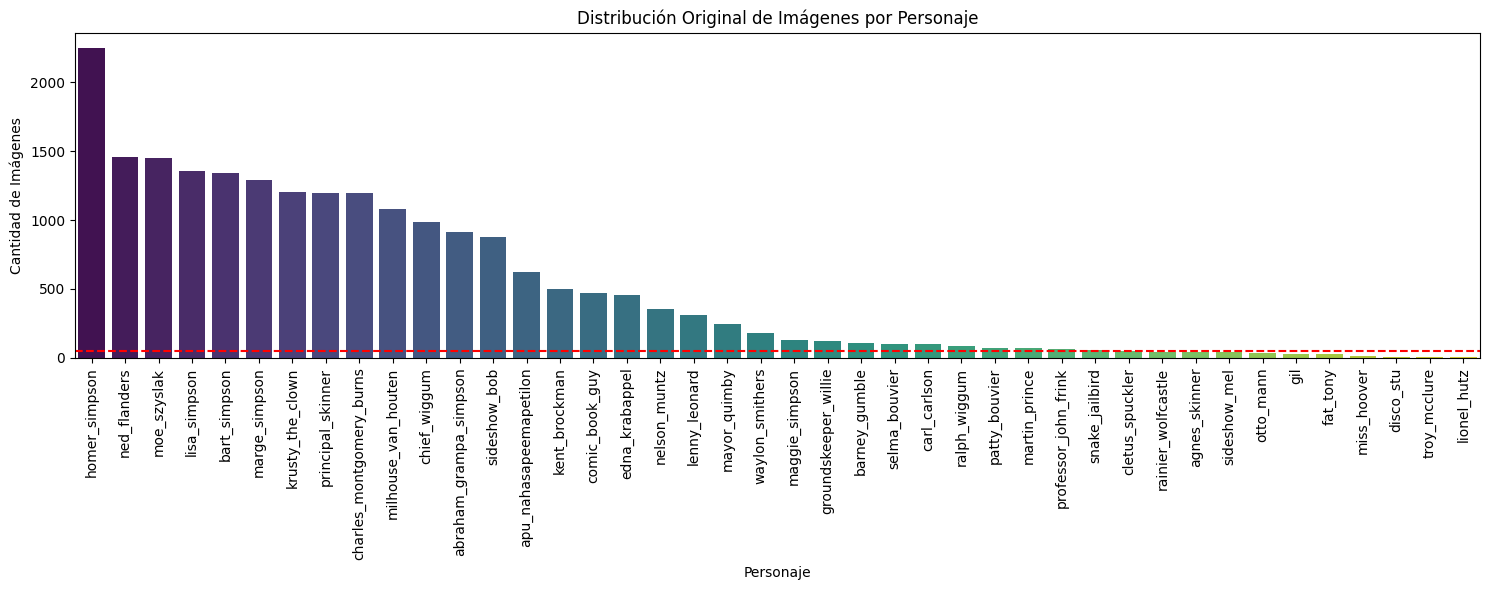

In [3]:
# Extraer la distribución original de clases
raw_ds = datasets.ImageFolder(SIMPSONS_DIR)
from collections import Counter
counts = Counter([label for _, label in raw_ds.samples])

class_counts = {raw_ds.classes[label]: count for label, count in counts.items()}
df_raw = pd.DataFrame(list(class_counts.items()), columns=['Personaje', 'Cantidad'])
df_raw = df_raw.sort_values('Cantidad', ascending=False).reset_index(drop=True)

total_images = df_raw['Cantidad'].sum()
df_raw['Proporcion (%)'] = (df_raw['Cantidad'] / total_images * 100).round(2)

print(f"Total de imágenes originales: {total_images}")
print(f"Total de clases originales: {len(df_raw)}")
print("Top 15 Clases Mayoritarias:")
display(df_raw.head(15))
print("\nTop 15 Clases Minoritarias:")
display(df_raw.tail(15))

plt.figure(figsize=(15, 6))
sns.barplot(data=df_raw, x='Personaje', y='Cantidad', hue='Personaje', palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Distribución Original de Imágenes por Personaje')
plt.axhline(50, color='red', linestyle='--', label='Umbral de filtrado (50)')
plt.ylabel('Cantidad de Imágenes')
plt.xlabel('Personaje')
plt.tight_layout()
plt.show()


## Hallazgos y Toma de Decisiones
Durante la exploración inicial y la posterior evaluación visual de los modelos, identificamos dos retos fundamentales en la calidad del dataset original que guiaron nuestras decisiones arquitectónicas:

Imágenes Mal Etiquetadas: Descubrimos errores desde el origen del dataset, como imágenes de Marge etiquetadas erróneamente como Mr. Burns, o incluso personajes que ni siquiera pertenecen a nuestras clases (como Ginger Flanders) clasificados dentro de la carpeta de Ned Flanders. Tomamos la decisión de mantener las imágenes tal como están para simular un entorno de producción del mundo real, donde los datos rara vez son perfectos. Curiosamente, gracias a la extracción robusta de características, nuestra CNN logró predecir correctamente al personaje visualizado en varios de estos casos, demostrando resistencia frente al "ruido" de las etiquetas.

Desbalance Extremo y Umbral de Clases: Como se observa en la distribución inicial, enfrentamos un problema de desbalance severo. Personajes secundarios como Lionel Hutz poseen menos de 10 imágenes en total. Intentar entrenar una red neuronal convolucional desde cero para que aprenda a generalizar un rostro con tan pocos ejemplos es matemáticamente inviable: provocaría una memorización absoluta (overfitting) en el entrenamiento y carecería de soporte estadístico válido en el conjunto de evaluación (Test).

Por lo tanto, la capa de datos fue programada para descartar automáticamente cualquier personaje que posea menos de 50 imágenes. Esto nos permitió consolidar un dataset acotado a 31 clases principales sólidas que sí son aptas para el aprendizaje profundo.

## Configuración y Pipeline de Datos

Definimos nuestros hiperparámetros de experimentación en una clase estática. Posteriormente, inicializamos nuestro módulo de datos, el cual aplicará el filtrado de clases, la aumentación y realizará la partición estratificada de los datos.

In [4]:
@dataclass
class Config:
    in_channels: int = 3
    image_size: int = 64
    batch_size: int = 128
    lr: float = 0.001
    weight_decay: float = 0.0001
    data_dir: str = '../data'

cfg = Config()

datamodule = SimpsonsDataModule(cfg)
datamodule.prepare_data()
datamodule.setup()



[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


## Análisis Exploratorio Post-Split

Tras ejecutar la partición, es importante comprobar cómo quedaron conformados los subconjuntos de Entrenamiento, Validación y Prueba. Analizaremos las cantidades y observaremos si la estratificación se aplicó correctamente para todas las clases que superaron el umbral.

Total imágenes Train: 14445
Total imágenes Val: 2064
Total imágenes Test: 4128


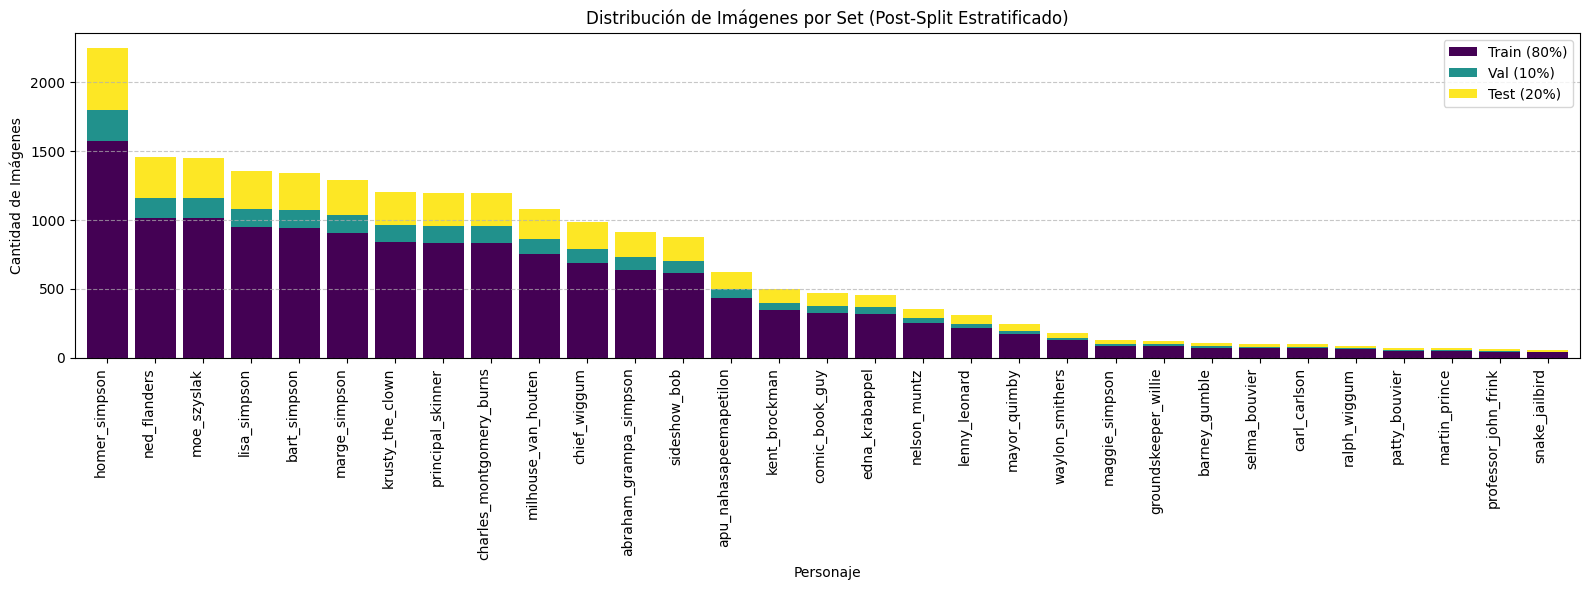

In [5]:
# Obtener conteos de las clases en cada subset resultante
train_counts = Counter([y for _, y in datamodule.train_ds])
val_counts = Counter([y for _, y in datamodule.val_ds])
test_counts = Counter([y for _, y in datamodule.test_ds])

idx_to_class = {i: k for i, k in enumerate(datamodule.classes)}
data_split = []
for idx in idx_to_class.keys():
    name = idx_to_class[idx]
    tr, va, te = train_counts.get(idx, 0), val_counts.get(idx, 0), test_counts.get(idx, 0)
    total = tr + va + te
    data_split.append({
        "Personaje": name, 
        "Train (80%)": tr, 
        "Val (10%)": va, 
        "Test (20%)": te,
        "Total": total
    })

df_split = pd.DataFrame(data_split).set_index("Personaje").sort_values("Total", ascending=False)

print(f"Total imágenes Train: {df_split['Train (80%)'].sum()}")
print(f"Total imágenes Val: {df_split['Val (10%)'].sum()}")
print(f"Total imágenes Test: {df_split['Test (20%)'].sum()}")

ax = df_split[["Train (80%)", "Val (10%)", "Test (20%)"]].plot(
    kind="bar", stacked=True, figsize=(16, 6), colormap="viridis", width=0.85
)
plt.title("Distribución de Imágenes por Set (Post-Split Estratificado)")
plt.ylabel("Cantidad de Imágenes")
plt.xlabel("Personaje")
plt.xticks(rotation=90, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Arquitectura del Modelo

A continuación, definimos desde cero nuestra Red Neuronal Convolucional (CNN).
Diseñaremos una arquitectura secuencial con bloques convolucionales que incluyen capas de normalización (Batch Normalization) para estabilizar el aprendizaje, y capas de MaxPooling para reducir la dimensionalidad. Al final, usaremos Global Average Pooling seguido de un regularizador Dropout para minimizar el riesgo de sobreajuste.

In [20]:
class CNN1(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, dropout_rate: float = 0.5):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class MLP1(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, dropout_rate: float = 0.5):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64 * in_channels, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        return self.classifier(x)


## Entrenamiento

Con la arquitectura construida y el pipeline de datos preparado, procedemos a entrenar el modelo. Emplearemos PyTorch Lightning como orquestador, el cual manejará los bucles de entrenamiento y validación de forma automática.
Compilamos nuestra red dentro de nuestro LightningModule y corremos el proceso durante 15 épocas. Adicionalmente comparamos a la arquitectura MLP.

Primero calculamos los pesos de clase para evitar el desbalance. Esto es clave para que el modelo no ignore a las clases minoritarias. 

Al aplicar Class Weights obligaremos a la red a penalizar fuertemente los errores cometidos en estas clases. Esperamos que esto aumente drásticamente la sensibilidad del modelo hacia estos personajes. Aunque esto pueda generar algunos falsos positivos a costa de la Precision, es un paso necesario para forzar a la red a aprender las características de todos los personajes.

In [6]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_targets = [y for _, y in datamodule.train_ds]

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_targets),
    y=train_targets
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32)

Entrenamos MLP1

In [ ]:
mlp_model = MLP1(in_channels=cfg.in_channels, num_classes=datamodule.num_classes)
mlp_module = SimpsonsModule(cfg, model=mlp_model, num_classes=datamodule.num_classes)

mlp_logger = CSVLogger("logs", name="mlp1")
trainer_mlp = L.Trainer(
    max_epochs=15,
    logger=mlp_logger,
    accelerator='auto',
    devices=1,
    enable_progress_bar=True
)

print("Entrenando MLP1")
trainer_mlp.fit(mlp_module, datamodule=datamodule)
print("\nEvaluando MLP1")
trainer_mlp.test(mlp_module, datamodule=datamodule)


=== Entrenando MLP1 ===

[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]


=== Evaluando MLP1 ===

[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.2869851589202881
      test/f1_macro         0.2821432650089264
        test/loss            2.140407085418701
     test/precision         0.3127574026584625
       test/recall          0.2869851589202881
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test/loss': 2.140407085418701,
  'test/acc': 0.2869851589202881,
  'test/f1_macro': 0.2821432650089264,
  'test/precision': 0.3127574026584625,
  'test/recall': 0.2869851589202881}]

Entrenamos CNN1

In [ ]:
cnn_model = CNN1(in_channels=cfg.in_channels, num_classes=datamodule.num_classes)
lightning_model = SimpsonsModule(cfg, model=cnn_model, num_classes=datamodule.num_classes, class_weights=class_weights_tensor)

cnn_logger = CSVLogger("logs", name="cnn1")
trainer = L.Trainer(
    max_epochs=15,
    logger=cnn_logger,
    accelerator='auto',
    devices=1,
    enable_progress_bar=True
)

trainer.fit(lightning_model, datamodule=datamodule)


[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## Comparación de Rendimiento

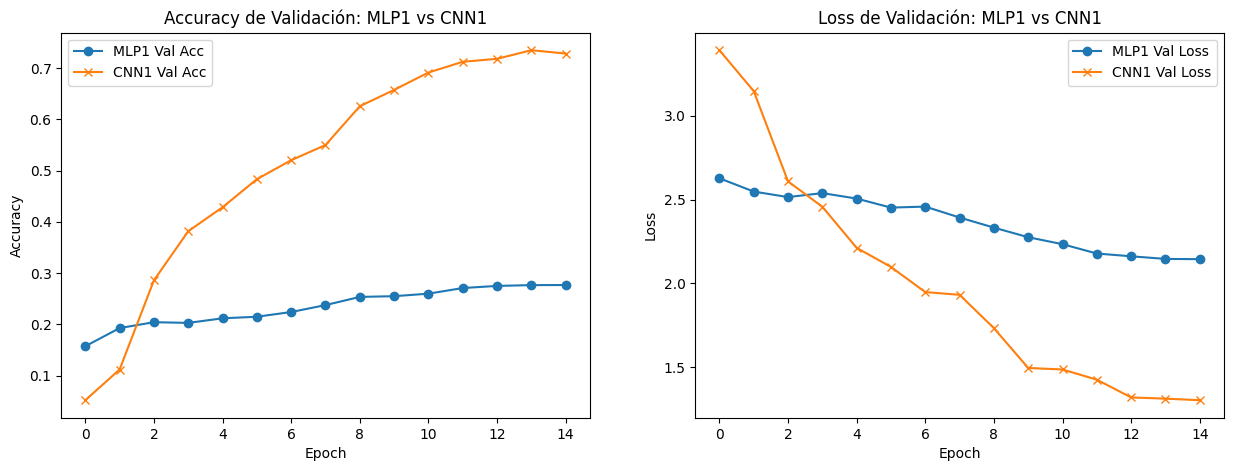

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

mlp_metrics = pd.read_csv(f"{mlp_logger.log_dir}/metrics.csv")
cnn_metrics = pd.read_csv(f"{cnn_logger.log_dir}/metrics.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

mlp_val_acc = mlp_metrics[['epoch', 'val/acc']].dropna()
cnn_val_acc = cnn_metrics[['epoch', 'val/acc']].dropna()
ax1.plot(mlp_val_acc['epoch'], mlp_val_acc['val/acc'], label='MLP1 Val Acc', marker='o')
ax1.plot(cnn_val_acc['epoch'], cnn_val_acc['val/acc'], label='CNN1 Val Acc', marker='x')
ax1.set_title('Accuracy de Validación: MLP1 vs CNN1')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

mlp_val_loss = mlp_metrics[['epoch', 'val/loss']].dropna()
cnn_val_loss = cnn_metrics[['epoch', 'val/loss']].dropna()
ax2.plot(mlp_val_loss['epoch'], mlp_val_loss['val/loss'], label='MLP1 Val Loss', marker='o')
ax2.plot(cnn_val_loss['epoch'], cnn_val_loss['val/loss'], label='CNN1 Val Loss', marker='x')
ax2.set_title('Loss de Validación: MLP1 vs CNN1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()


El Perceptrón Multicapa (MLP) presenta un aprendizaje muy limitado. Aunque comienza disminuyendo la pérdida (loss) marginalmente, su métrica de accuracy se estanca prematuramente cerca del 28% después de apenas 8 épocas. Esto ocurre porque la arquitectura MLP requiere aplanar (flatten) las imágenes de entrada en vectores unidimensionales, destruyendo la estructura espacial bidimensional de los datos. Al perder el contexto espacial, la red es incapaz de capturar características locales vitales (como bordes, siluetas o texturas geométricas) y, por ende, carece de información valiosa para seguir generalizando.

Por el contrario, la Red Neuronal Convolucional (CNN) demuestra un aprendizaje pronunciado y constante a lo largo de las 15 épocas. Aunque comienza con una pérdida inicial mayor, rápidamente supera al MLP alrededor de la época 3, reduciendo la pérdida drásticamente y elevando el accuracy por encima del 70%. Esto se debe al sesgo inductivo (inductive bias) de las operaciones convolucionales, las cuales preservan la topología local de la imagen. A través del uso de filtros (kernels) y capas de pooling, la CNN extrae jerárquicamente características visuales clave, demostrando su enorme superioridad y potencial intrínseco para procesar y generalizar datos de naturaleza visual.

## Evaluación

Sometemos al modelo entrenado contra el subconjunto de pruebas (Test Set), un 20% de las imágenes originales que la red jamás ha visto.
Utilizamos nuestro módulo de visualización para extraer todas las métricas, graficar las curvas de pérdida y precisión, trazar la matriz de confusión detallada, y aplicar técnicas de explicabilidad (Grad-CAM) para analizar en qué píxeles se centró la red neuronal al tomar sus decisiones.


Evaluando CNN

[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.7691942453384399
      test/f1_macro         0.6509648561477661
        test/loss           1.5027083158493042
     test/precision          0.620285153388977
       test/recall          0.7691942453384399
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


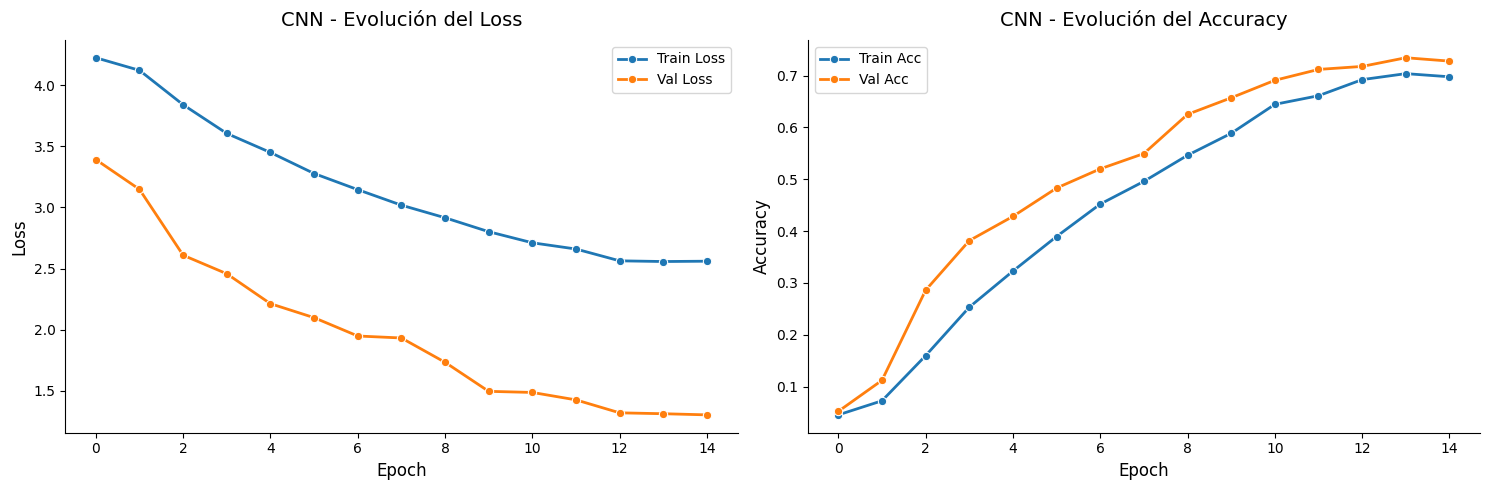


--- Reporte de Clasificación ---
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.69      0.84      0.75       183
  apu_nahasapeemapetilon       0.86      0.92      0.89       125
           barney_gumble       0.45      0.81      0.58        21
            bart_simpson       0.64      0.43      0.51       268
            carl_carlson       0.66      0.95      0.78        20
charles_montgomery_burns       0.72      0.50      0.59       239
            chief_wiggum       0.88      0.91      0.90       197
          comic_book_guy       0.77      0.70      0.73        94
          edna_krabappel       0.75      0.87      0.80        91
    groundskeeper_willie       0.53      1.00      0.70        24
           homer_simpson       0.89      0.57      0.69       449
           kent_brockman       0.79      0.92      0.85       100
        krusty_the_clown       0.86      0.93      0.90       241
           lenny_leonard       0.52      

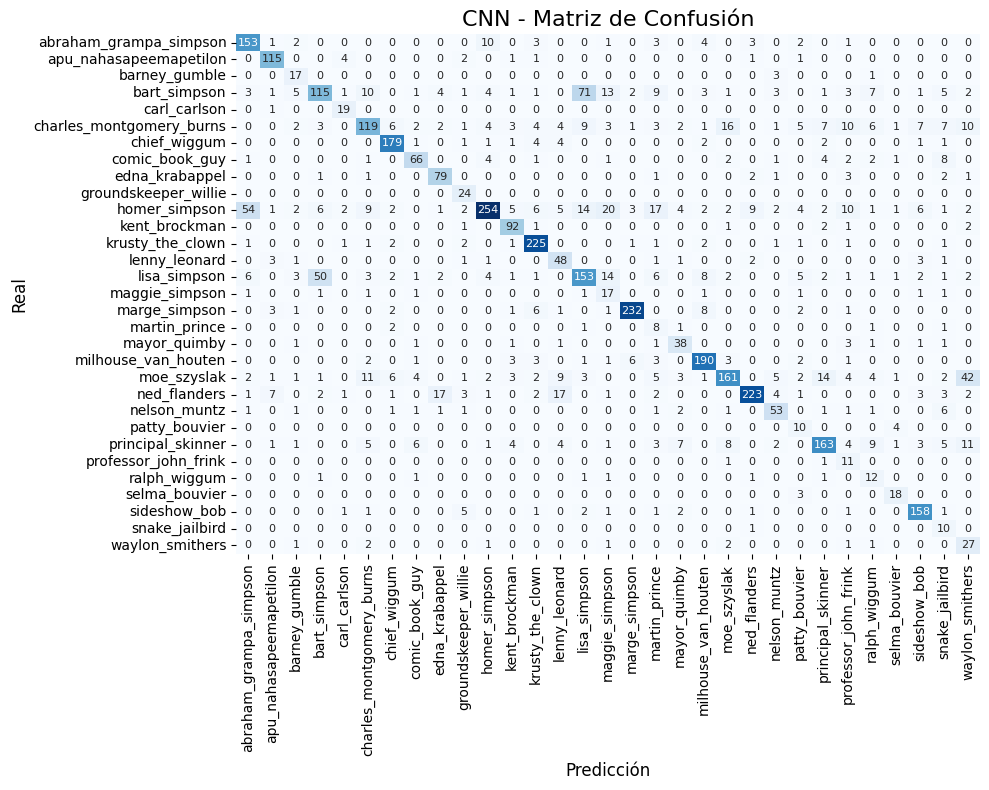

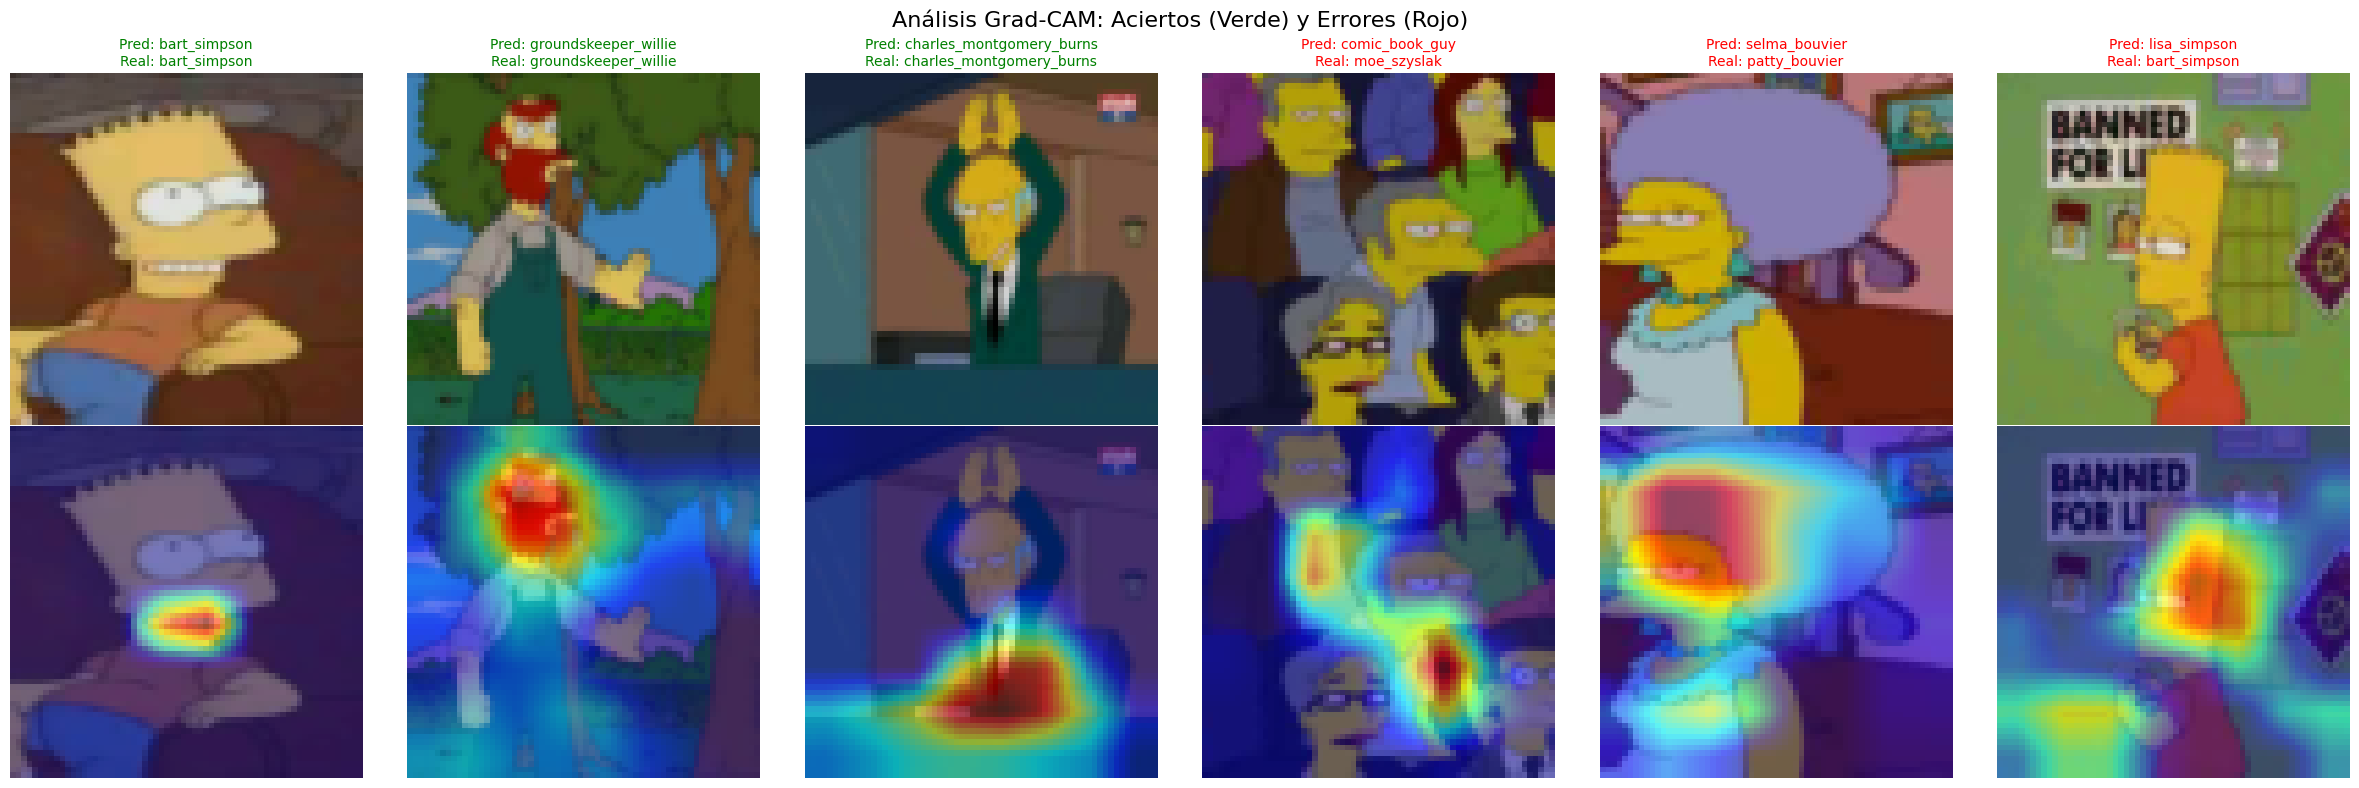

In [ ]:
# Seleccionamos la última capa convolucional para Grad-CAM
target_layer = lightning_model.model.features[-4]

# Evaluar
evaluate_model(
    model=lightning_model, 
    trainer=trainer, 
    datamodule=datamodule, 
    history=pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv").to_dict("records"),
    target_layer=target_layer,
    title="CNN1"
)


Las curvas de evolución muestran un proceso de aprendizaje estable, respaldado por el uso de Batch Normalization y Dropout. El Validation Loss desciende de manera pronunciada y comienza a estabilizarse alrededor de la época 12, logrando un Validation Accuracy cercano al 73%. El modelo converge adecuadamente sin signos graves de sobreajuste (overfitting), demostrando que una arquitectura convolucional es el camino correcto para este tipo de datos.

El análisis de explicabilidad mediante Grad-CAM revela mucho sobre el aprendizaje del modelo. Por un lado, la red logra extraer patrones lógicos para distinguir personajes. Sin embargo, muestra claras debilidades de atención: en predicciones correctas, el modelo a menudo toma "atajos visuales", enfocándose en áreas muy limitadas (como únicamente la boca de Bart o la parte inferior del traje/escritorio de Mr. Burns) en lugar de aprender las facciones completas del rostro. En las predicciones incorrectas, estas vulnerabilidades se hacen más evidentes. La matriz de confusión y el Grad-CAM muestran que la red es altamente susceptible al ruido del fondo o a la presencia de personajes secundarios (como ocurre en el error de predicción de Moe), y tiene dificultades severas para distinguir personajes con siluetas y paletas de color casi idénticas (como la confusión entre Patty y Selma).

## Optimizacion

### Definición de CNN2
Reemplazamos la etapa de `Flatten` por `Global Average Pooling` y agregamos un quinto bloque convolucional.

In [10]:
class CNN2(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, dropout_rate: float = 0.5):
        super().__init__()
        
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloque 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            #Bloque 5
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)) #GAP: Global Average Pooling
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes) #Capa única, Menos parámetros, menos overfitting.
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### Entrenamiento de CNN2
Entrenamos con la misma configuración y `class_weights` para comparar de forma justa.

In [ ]:
cnn2_model = CNN2(in_channels=cfg.in_channels, num_classes=datamodule.num_classes)
lightning_model_2 = SimpsonsModule(cfg, model=cnn2_model, num_classes=datamodule.num_classes, class_weights=class_weights_tensor)

cnn2_logger = CSVLogger("logs", name="cnn2")
trainer2 = L.Trainer(
    max_epochs=15,
    logger=cnn2_logger,
    accelerator='auto',
    devices=1,
    enable_progress_bar=True
)

trainer2.fit(lightning_model_2, datamodule=datamodule)


[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Evaluando CNN

[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.8858006596565247
      test/f1_macro          0.77142333984375
        test/loss           0.9269596338272095
     test/precision         0.7397542595863342
       test/recall          0.8858006596565247
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


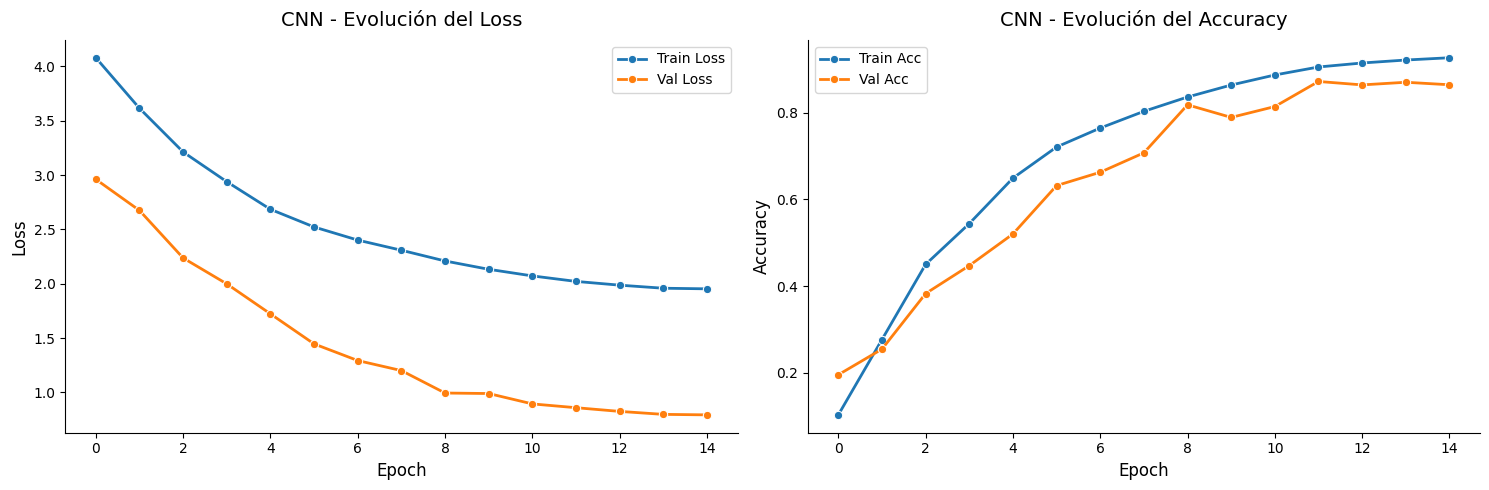


--- Reporte de Clasificación ---
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.90      0.91      0.91       183
  apu_nahasapeemapetilon       0.94      0.97      0.95       125
           barney_gumble       0.40      0.95      0.56        21
            bart_simpson       0.91      0.79      0.84       268
            carl_carlson       0.49      0.95      0.64        20
charles_montgomery_burns       0.96      0.74      0.83       239
            chief_wiggum       0.96      0.95      0.95       197
          comic_book_guy       0.92      0.86      0.89        94
          edna_krabappel       0.91      0.91      0.91        91
    groundskeeper_willie       0.52      1.00      0.69        24
           homer_simpson       0.97      0.79      0.87       449
           kent_brockman       0.92      0.92      0.92       100
        krusty_the_clown       0.95      0.95      0.95       241
           lenny_leonard       0.83      

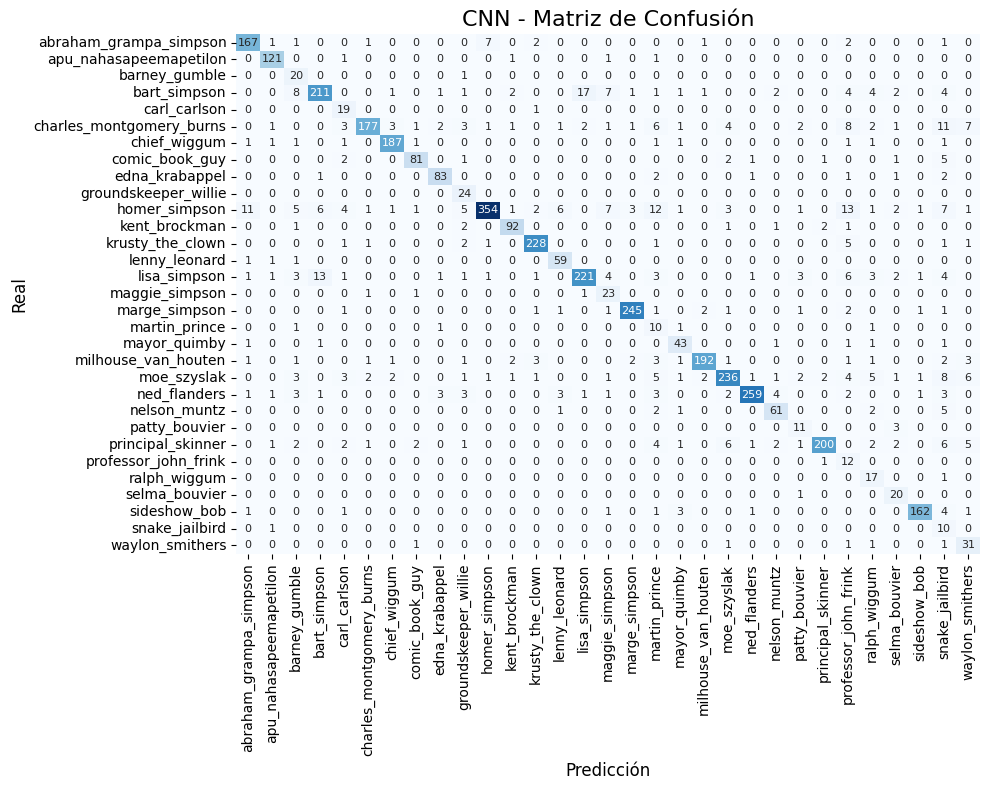

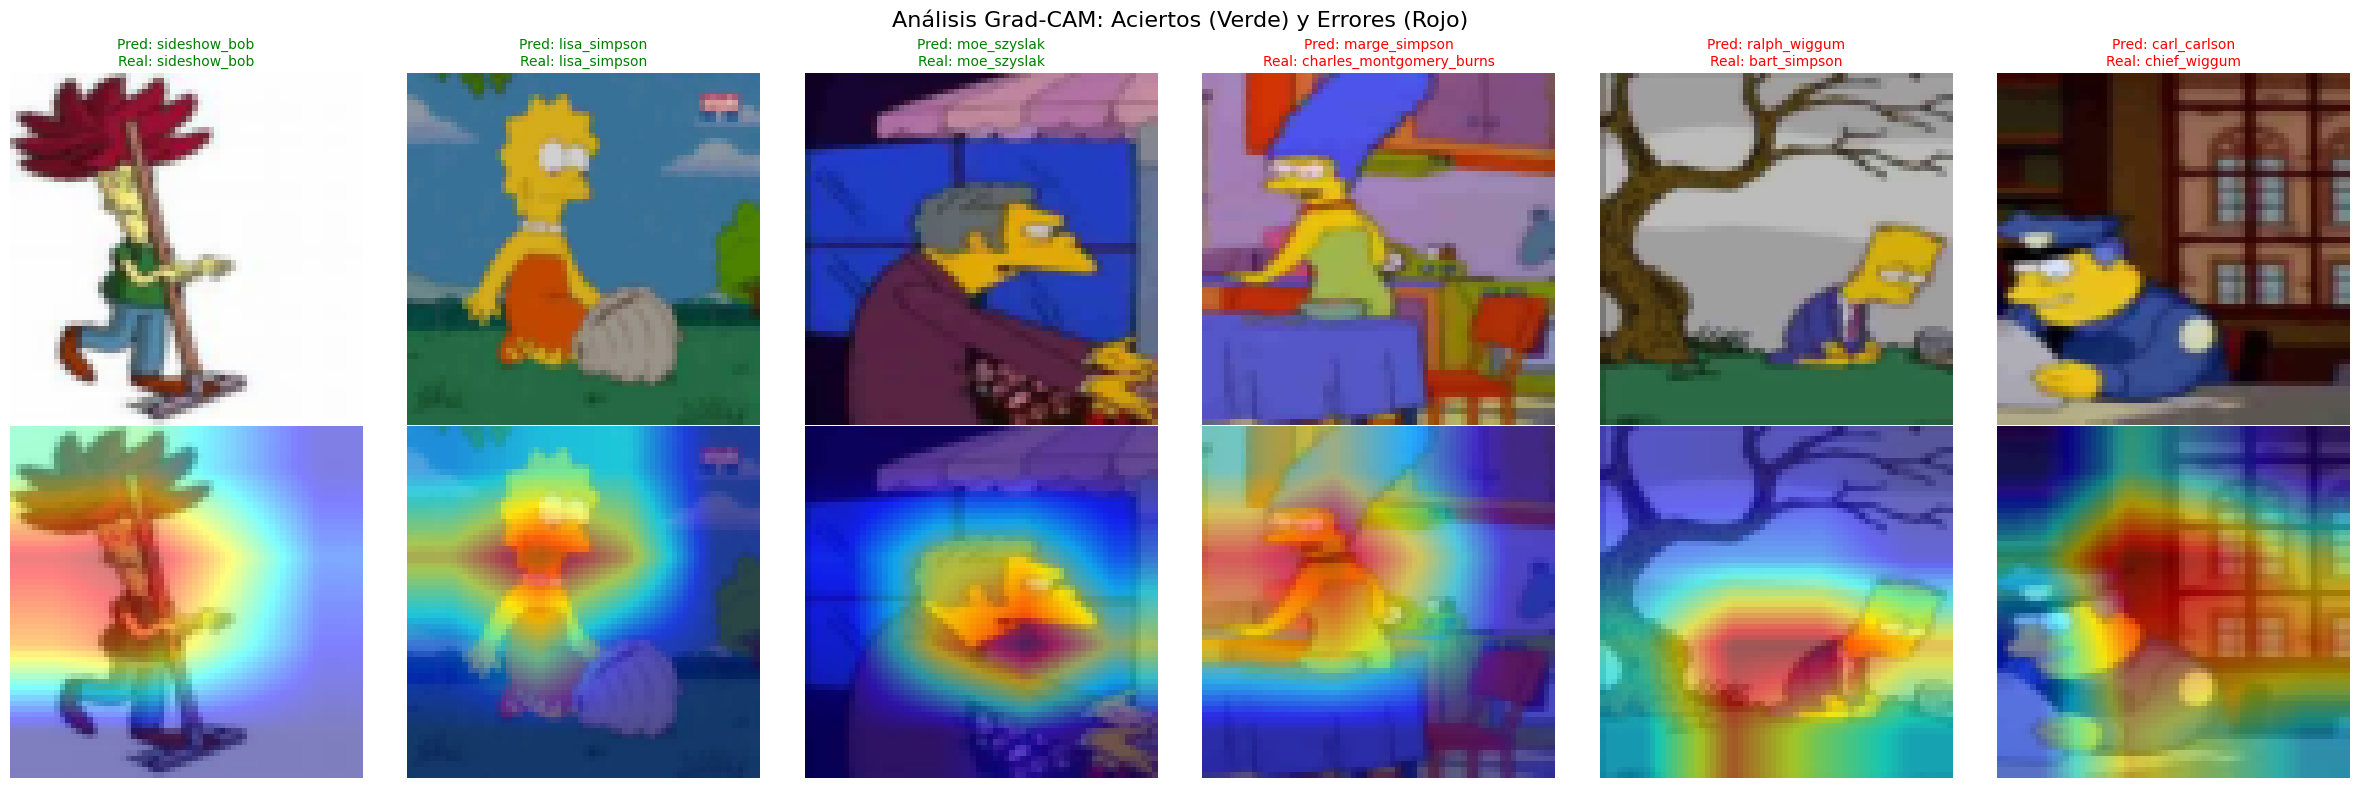

In [10]:
# En CNN2, features[-1] es AdaptiveAvgPool2d, [-2] es ReLU, [-3] es BatchNorm, [-4] es Conv2d
target_layer_2 = lightning_model_2.model.features[-4]

cnn2_metrics = pd.read_csv(f"{cnn2_logger.log_dir}/metrics.csv")

evaluate_model(
    history=cnn2_metrics,
    model=lightning_model_2, 
    trainer=trainer2, 
    datamodule=datamodule, 
    target_layer=target_layer_2
)

^ 4ta columna, evidencia la robustez contra etiquetas ruidosas.

## CNN3, Data aug

### Configuración del DataModule con Augmentations
Aplicamos transformaciones aleatorias (espejo, rotación, color) únicamente a las imágenes de entrenamiento para simular variabilidad.

In [8]:
from torchvision.transforms import v2

# Definimos transformaciones robustas SOLO para el entrenamiento
train_transforms_aug = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((cfg.image_size, cfg.image_size)),
    v2.RandomHorizontalFlip(p=0.5), # Efecto espejo (50% de prob)
    v2.RandomRotation(degrees=15),  # Rotación leve
    v2.ColorJitter(brightness=0.2, contrast=0.2), # Cambios de luz
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instanciamos un nuevo DataModule que use estas transformaciones
datamodule_aug = SimpsonsDataModule(
    cfg, 
    train_transforms=train_transforms_aug
    # val_transforms se mantiene por defecto (sin augmentations, solo resize/norm)
)

datamodule_aug.setup()



[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


### Entrenamiento CNN3
Entrenaremos la misma arquitectura de la CNN2, pero ahora consumiendo el `datamodule_aug` y durante 20 épocas ya que el aumento de datos requerira más tiempo para converger.

In [ ]:
# Reutilizamos exactamente la misma arquitectura de CNN2
cnn3_model = CNN2(in_channels=cfg.in_channels, num_classes=datamodule_aug.num_classes)
lightning_model_3 = SimpsonsModule(cfg, model=cnn3_model, num_classes=datamodule_aug.num_classes, class_weights=class_weights_tensor)

from lightning.pytorch.loggers import CSVLogger
cnn3_logger = CSVLogger("logs", name="cnn3_aug")

trainer3 = L.Trainer(
    max_epochs=20,
    logger=cnn3_logger,
    accelerator='auto',
    devices=1,
    enable_progress_bar=True
)

trainer3.fit(lightning_model_3, datamodule=datamodule_aug)



[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

### Evaluación


=== Evaluando CNN3 ===

Evaluando CNN

[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.9060221314430237
      test/f1_macro         0.7970178127288818
        test/loss           0.8846885561943054
     test/precision         0.7564135193824768
       test/recall          0.9060221314430237
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


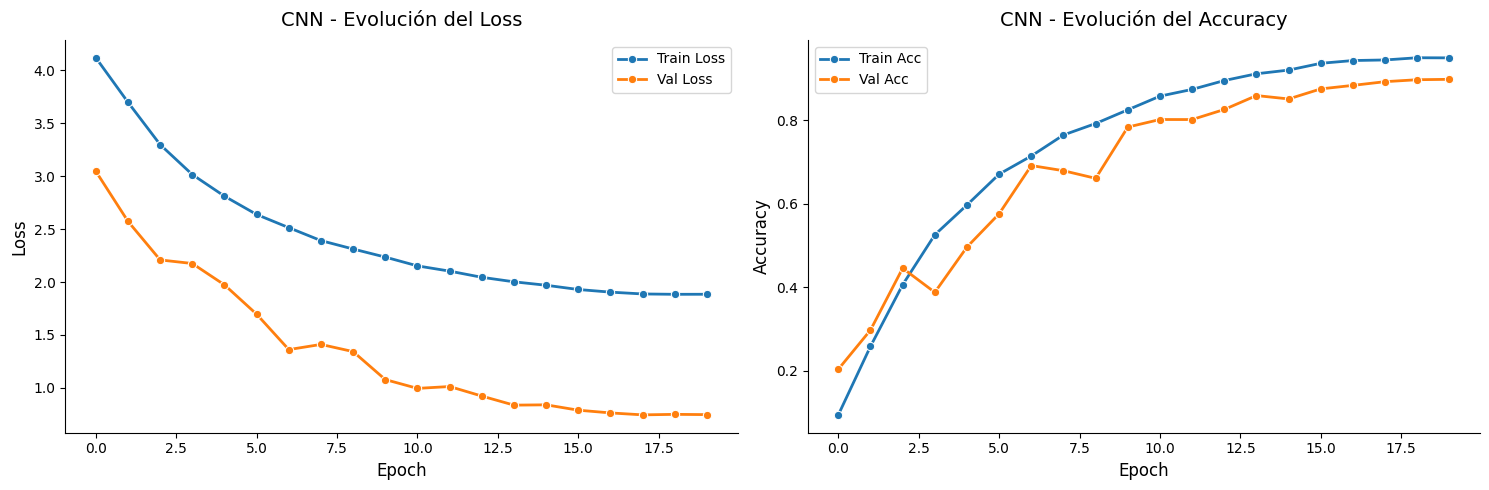


--- Reporte de Clasificación ---
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.90      0.94      0.92       183
  apu_nahasapeemapetilon       0.90      0.97      0.93       125
           barney_gumble       0.38      0.86      0.53        21
            bart_simpson       0.93      0.84      0.88       268
            carl_carlson       0.51      0.95      0.67        20
charles_montgomery_burns       0.96      0.75      0.84       239
            chief_wiggum       0.97      0.96      0.96       197
          comic_book_guy       0.93      0.94      0.93        94
          edna_krabappel       0.91      0.95      0.92        91
    groundskeeper_willie       0.59      1.00      0.74        24
           homer_simpson       0.97      0.83      0.89       449
           kent_brockman       0.93      0.95      0.94       100
        krusty_the_clown       0.98      0.96      0.97       241
           lenny_leonard       0.75      

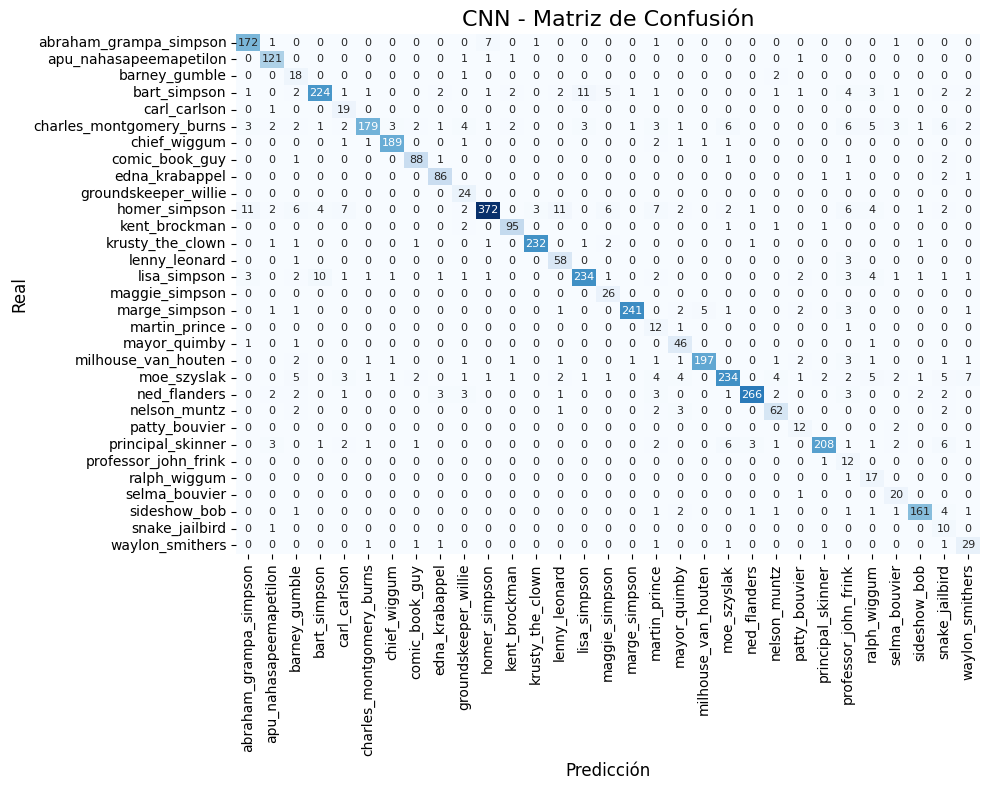

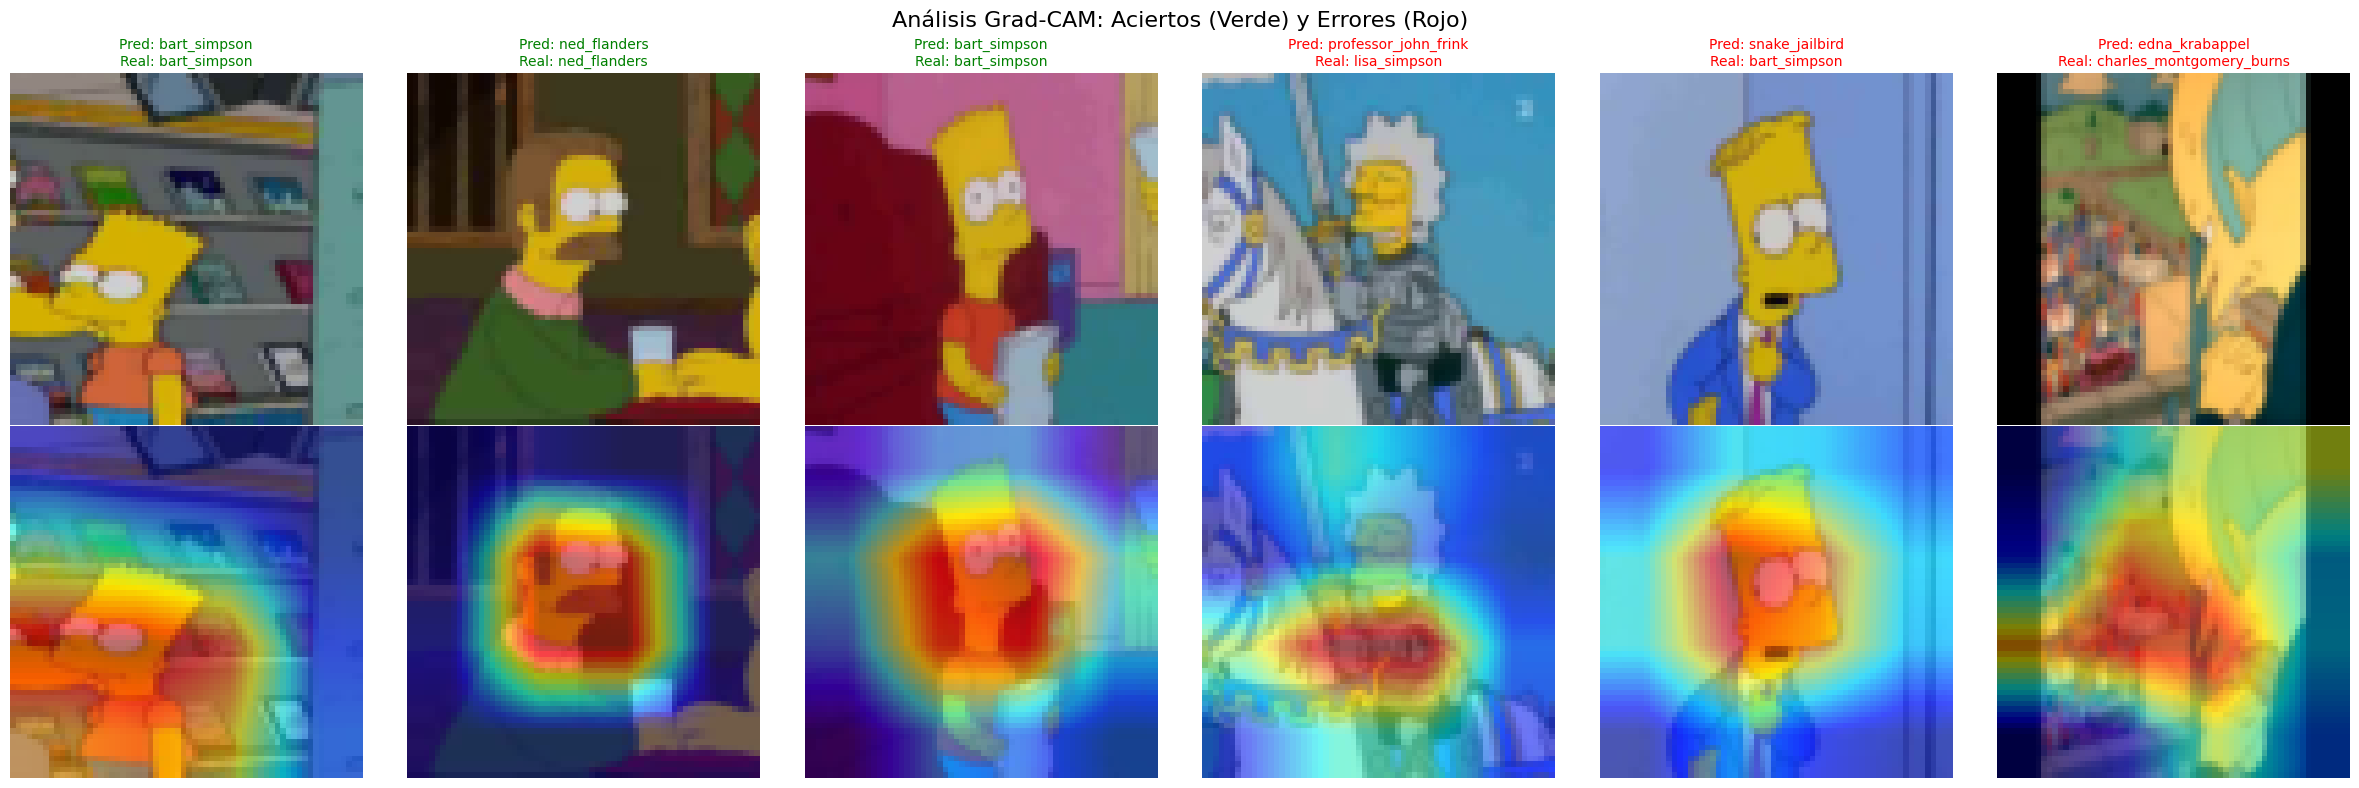

In [12]:
import pandas as pd

# 1. Leer las métricas
cnn3_metrics = pd.read_csv(f"{cnn3_logger.log_dir}/metrics.csv")

# 2. Seleccionar la última capa convolucional para Grad-CAM
target_layer_3 = lightning_model_3.model.features[-4]

print("\n=== Evaluando CNN3 ===")
evaluate_model(
    history=cnn3_metrics,
    model=lightning_model_3, 
    trainer=trainer3, 
    datamodule=datamodule_aug, 
    target_layer=target_layer_3
)


La introducción de Data Augmentation mejoró nuestras métricas, alcanzando un Accuracy global de 0.89 y un Macro F1 de 0.80, aunque el análisis revela que aún existe un claro margen de mejora.

Las curvas de aprendizaje muestran que la brecha entre el Train Loss y el Val Loss se redujo significativamente. Al aplicar distorsiones aleatorias (espejo, rotaciones, brillo) durante el entrenamiento, logramos mitigar el sobreajuste (overfitting). El modelo dejó de memorizar detalles fijos de las imágenes y mejoró su generalización, lo cual se evidenció en un aumento del Recall general, especialmente en las clases minoritarias que se beneficiaron de esta variabilidad simulada.

Los mapas de atención (Grad-CAM) confirman que la red logra centrarse en los rostros e ignorar el fondo en la mayoría de los casos. Sin embargo, los falsos positivos en la matriz de confusión demuestran las limitaciones actuales de nuestra arquitectura. La red aún presenta dificultades cuando los personajes aparecen en ángulos extremos, con disfraces o bajo iluminaciones atípicas. Para futuras iteraciones, el rendimiento podría incrementarse explorando arquitecturas más profundas mediante Transfer Learning o aplicando técnicas sintéticas de Oversampling para las clases más severamente desbalanceadas.

# Conclusiones

A lo largo de este proyecto, hemos desarrollado y evaluado progresivamente distintas arquitecturas para resolver el problema de clasificación de personajes de *Los Simpsons*, enfrentando retos reales como el desbalance extremo de clases y la presencia de etiquetas ruidosas (imágenes mal etiquetadas).

## Evolución de la Arquitectura
* **Perceptrón Multicapa (MLP) vs CNN Base:** Comprobamos empíricamente que las redes neuronales densas carecen de invariancia espacial, perdiendo información valiosa al aplanar la imagen. La CNN Base solucionó esto, pero fallaba estrepitosamente en clases minoritarias debido al desbalance.
* **Manejo de Desbalance (Class Weights):** Al penalizar los errores en clases minoritarias, el modelo dejó de ignorarlas. Sin embargo, reveló un sobreajuste estructural (*overfitting*), donde la red memorizaba el fondo en lugar del rostro.
* **CNN2 (Global Average Pooling):** La incorporación de GAP eliminó la dependencia espacial estricta de las capas *Fully Connected*, y el Dropout forzó a la red a no depender de características específicas. Esto mejoró sustancialmente la generalización y, como evidenció el análisis de *Grad-CAM*, obligó a la red a prestar atención a los rostros.
* **CNN3 (Data Augmentation):** El modelo final abordó el último problema: la memorización de ángulos y luz. Al inyectar rotaciones, efecto espejo y variaciones de brillo de forma aleatoria, cerramos la brecha entre el *Train Loss* y el *Val Loss*.

## Elección del Modelo Final y su Impacto
Seleccionamos la CNN3 como nuestro modelo definitivo. Esta decisión se fundamenta técnicamente en sus métricas superiores (Accuracy del 89% y Macro F1 del 80%) frente a las iteraciones anteriores. 

Más allá de los números, su verdadero impacto en la solución del caso de estudio radica en su robustez:
1. **Inclusión:** Gracias a los pesos de clase y al aumento de datos, es capaz de reconocer con un *Recall* casi perfecto a personajes secundarios que apenas contaban con 50 imágenes.
2. **Explicabilidad:** El uso de herramientas visuales (*Grad-CAM*) nos permite confiar en el modelo, asegurando que sus predicciones se basan en características semánticas reales (el rostro, los ojos) y no en sesgos del fondo de la imagen.
3. **Resiliencia al Ruido:** Como se demostró durante el análisis exploratorio, el modelo logró sobreponerse a errores humanos en el dataset original (como la confusión de etiquetas entre Marge y Mr. Burns), evidenciando que está listo para operar en un entorno de producción del mundo real donde la calidad de los datos es imperfecta.
